This file acts as a playground to determine f.e. the ideal Interval for the Analysis

In [1]:

Patient = "P015" #"P015/P015_S01_D2024-07-06"
run = "S01"
date = "2024-07-06"

In [12]:
import importlib
import analyzer
importlib.reload(analyzer)
from analyzer import Analyzer
import matplotlib.pyplot as plt
import pandas as pd
import re
import os
import json
import numpy as np




analysis = Analyzer(
        filename=f"Data/{Patient}/{Patient}_{run}_D{date}.tdms",
        add_filename=f"Data/{Patient}/{Patient}_{run}_D{date}_addCh.tdms",
        log_file_path=f"Data/{Patient}/QZFM_log_file.txt",
        sensor_channels_to_exclude={"Brustlage": ["NL_x", "EY_x"]},
        #model_checkpoint_dir=f"MCG_segmentation/trained_models/UNet_1D_900k",
    )

key = "Brustlage"  # "Bauchlage", "Brustlage", "Rechtslage", "LinksLage"
(x_data, y_data, z_data), time, single_run = analysis.prepare_data(key, apply_default_filter=True, plot_alignment=True)


2025-07-22 13:36:03,934 - INFO - Using device: mps
2025-07-22 13:36:03,937 - ERROR - Error importing TDMS file Data/P015/P015_S01_D2024-08-29.tdms: [Errno 2] No such file or directory: 'Data/P015/P015_S01_D2024-08-29.tdms'
2025-07-22 13:36:03,937 - INFO - Loaded primary TDMS file: Data/P015/P015_S01_D2024-08-29.tdms
2025-07-22 13:36:03,937 - ERROR - Error importing TDMS file Data/P015/P015_S01_D2024-08-29_addCh.tdms: [Errno 2] No such file or directory: 'Data/P015/P015_S01_D2024-08-29_addCh.tdms'
2025-07-22 13:36:03,938 - INFO - Loaded additional TDMS file: Data/P015/P015_S01_D2024-08-29_addCh.tdms
2025-07-22 13:36:03,939 - INFO - Loaded sensor log file: Data/P015/QZFM_log_file.txt
/Users/samuelfriese/Desktop/Bachelorarbeit/venv/lib/python3.11/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warning

KeyError: 'Brustlage'

# Find fitting intervall

In [ ]:
intervall_start = -15000
intervall_end = -5000


analysis.butterfly_plot(single_run[: :, intervall_start:intervall_end], time[intervall_start:intervall_end], single_run.shape[0], "Brustlage")

## Apply ICA filtering 

In [ ]:


x_data_intervall = x_data[:, :, intervall_start:intervall_end]
y_data_intervall = y_data[:, :, intervall_start:intervall_end]
z_data_intervall = z_data[:, :, intervall_start:intervall_end]
time_intervall = time[intervall_start:intervall_end]
single_run_intervall = single_run[:, intervall_start:intervall_end]


#analysis.plot4x4(z_data[:, :, 250:1250], time[250:1250], name="z_data")

x_data_filtered, _, _, _ = analysis.ICA_filter(x_data_intervall, heart_beat_score_threshold=0.70, plot_result=True)
y_data_filtered, ica_components, _, _ = analysis.ICA_filter(y_data_intervall, heart_beat_score_threshold=0.70, plot_result=True)
z_data_filtered, _, _, _ = analysis.ICA_filter(z_data_intervall, heart_beat_score_threshold=0.70, plot_result=True)

#print(ica_components.shape)
#analysis.plot_sensor_matrix(ica_components[:, :500].reshape(4, 4, -1), time_intervall[:500], name="ica_components")

Improve Windowing

In [ ]:
single_run_filtered = single_run_intervall#analysis.invert_field_directions(x_data_filtered, y_data_filtered, z_data_filtered, key, 48)


analysis.butterfly_plot(single_run_filtered, time_intervall, 48, f"Original {key}")


analysis.find_cleanest_channel(single_run_filtered)

# use cleanest channel for peak detection
peak_positions, ch, labels, _, _ = analysis.detect_qrs_complex_peaks_cleanest_channel(single_run_filtered, print_heart_rate=True, confidence_threshold=0.7, confidence_weight=1, plausibility_weight=0)
if peak_positions is not None and len(peak_positions) > 0:
    plt.figure(figsize=(12, 4))
    plt.plot(single_run_filtered[ch, :], label='Signal', linewidth=1.2)
    #plt.plot(resampled_data[ch, :], label='Signal', linewidth=1.2)
    plt.plot(peak_positions, single_run_filtered[ch, peak_positions], "ro", markersize=6, label='R Peaks')
    plt.title(f"QRS Detection - Cleanest Channel {ch + 1}")
    plt.xlabel("Time (samples)")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("No R peaks detected or `peak_positions` is empty.")
analysis.plot_segmented_signal(single_run_filtered[ch, :], labels[ch, :])


# window averaging
avg_channels, time_window = analysis.avg_window(single_run_filtered, peak_positions, window_left=0.3, window_right=0.5)
analysis.butterfly_plot(avg_channels, time_window, 48, f"Original {key}")


x_data_window, y_data_window, z_data_window = analysis.get_field_directions(avg_channels, key)

analysis.plot_sensor_matrix(x_data_window, time_window, name="X-Field")
analysis.plot_sensor_matrix(y_data_window, time_window, name="Y-Field")
analysis.plot_sensor_matrix(z_data_window, time_window, name="Z-Field")



## ICD Analysis

2025-07-22 13:40:04,289 - INFO - Loaded primary TDMS file: Data/P035/P035_S01_D2025-06-26.tdms
2025-07-22 13:40:04,573 - INFO - Loaded additional TDMS file: Data/P035/P035_S01_D2025-06-26_addCh.tdms
2025-07-22 13:40:04,575 - INFO - Loaded sensor log file: Data/P035/QZFM_log_file.txt
2025-07-22 13:40:04,575 - INFO - Available runs: Brustlage, Rueckenlage, Noise
/Users/samuelfriese/Desktop/Bachelorarbeit/venv/lib/python3.11/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(
2025-07-22 13:40:04,704 - INFO - Model loaded from MCG_segmentation/trained_models/MCGSegmentator_s/checkpoints/best/model.pth
2025-07-22 13:40:06,339 - INFO - Resampling data from 1000Hz to 250Hz. Target length: 73148, Original length: 292592 samples.


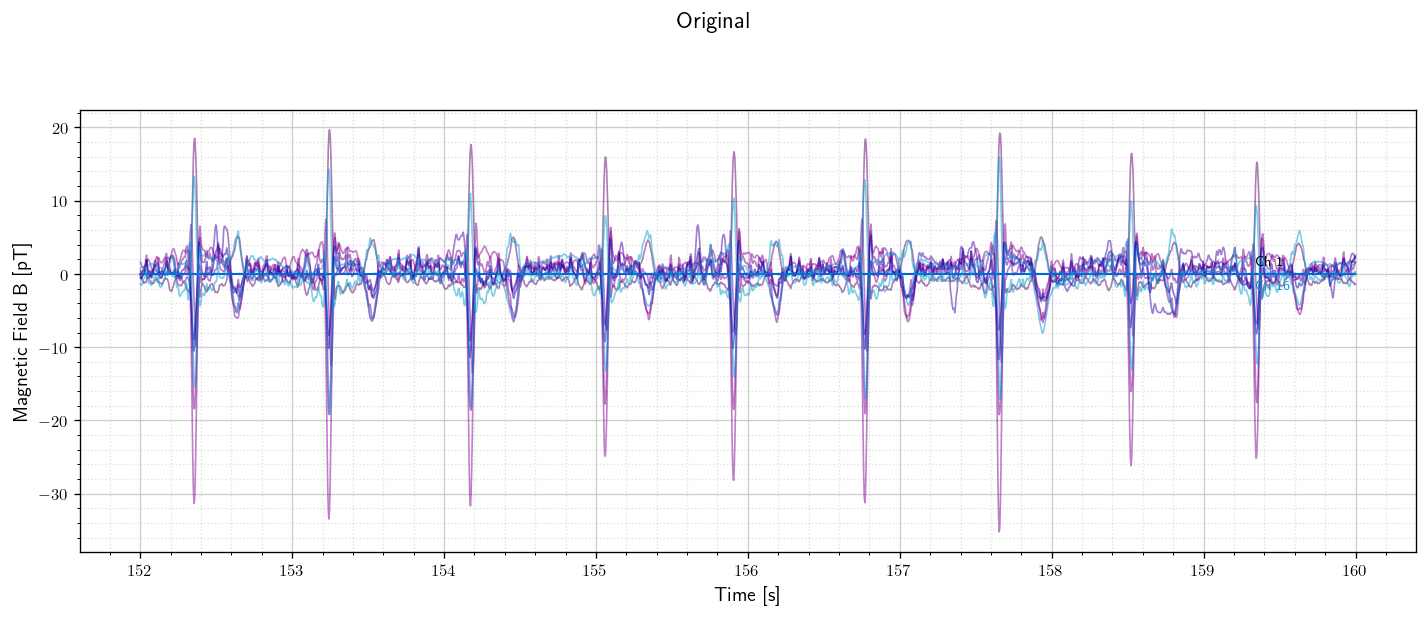

/Users/samuelfriese/Desktop/Bachelorarbeit/venv/lib/python3.11/site-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 25000 is greater than input length  = 2000, using nperseg = 2000
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


Legend suppressed due to too many entries.


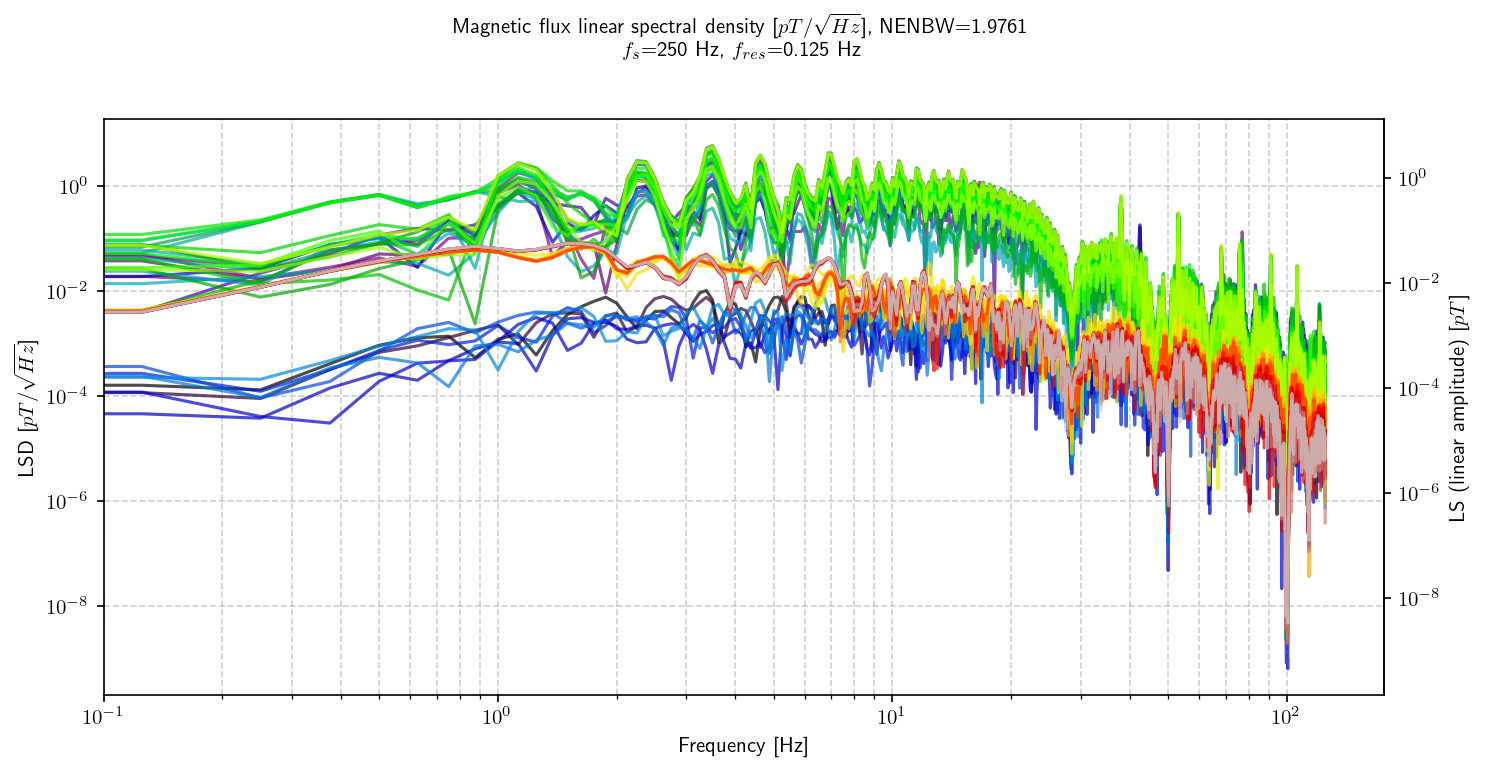

In [18]:
patient = "P035" #"P015/P015_S01_D2024-07-06"
date = "2025-06-26"
run = "S01"

log_file_path = f"Data/{patient}/QZFM_log_file.txt"
add_filename = f"Data/{patient}/{patient}_{run}_D{date}_addCh.tdms"
file_name = f"Data/{patient}/{patient}_{run}_D{date}.tdms"

analysis = Analyzer(
        filename=file_name,
        add_filename=add_filename,
        log_file_path=log_file_path,
        model_checkpoint_dir="MCG_segmentation/trained_models/MCGSegmentator_s",
        sensor_channels_to_exclude={}
    )

(x_data, y_data, z_data), time, single_run = analysis.prepare_data("Brustlage", apply_default_filter=True, plot_alignment=False)

single_run = single_run[:, 38000:40000]
time = time[38000:40000]

analysis.butterfly_plot(single_run, time, 16, f"Original")


# Example: Apply LSD plotting to QRS-aligned average data
channels_to_plot = list(range(single_run.shape[0]))  # or a subset if too many

# Call your function
analysis.plot_lsd_multichannel(
    data=single_run,
    channels=channels_to_plot,
)

